# ISIC 2020: Eksplorativna analiza podataka (EDA)

Ovaj notebook pruža detaljan uvid u dataset kroz sledeće celine:
1. **Analiza metapodataka** - provera strukture i distribucije CSV podataka.
2. **Analiza vizuelnog sadržaja** - ispitivanje dimenzija slika, detekcija duplikata i vizuelni pregled.
3. **Napredna statistika** - korelacije između karakteristika i automatska klasterizacija.

---

## 1. Učitavanje biblioteka i podešavanje
U ovoj fazi učitane su sve potrebne Python biblioteke za analizu podataka, vizualizaciju i rad sa slikama. Takođe, podešeni su parametri prikaza (npr. veličina grafika, stil plotova) kako bi rezultati bili pregledni i konzistentni kroz ceo notebook.

In [1]:
# Osnovne biblioteke
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Biblioteke za obradu slika
import cv2
from PIL import Image
import os
from pathlib import Path

In [3]:
# Biblioteke za napredne analize
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

## 2. Učitavanje metapodataka
Učitani su metapodaci iz CSV fajla koji sadrži informacije o slikama i pacijentima (ID, pol, starost, anatomska lokacija, ciljna promenljiva itd.). Proverena je ispravnost učitavanja i osnovna struktura podataka.

In [4]:
# Putanje do podataka
DATA_PATH = "/media/milos/Apacer PHD/sve/melanom-detection/"
TRAIN_CSV = os.path.join(DATA_PATH, "data.csv")
IMAGE_FOLDER = os.path.join(DATA_PATH, "train/")

In [5]:
# Ucitavanje metapodataka
df = pd.read_csv(TRAIN_CSV)
print(f"Ucitano {len(df)} redova i {len(df.columns)} kolona")
df.head()

Ucitano 33126 redova i 8 kolona


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


### 2.1 Osnovne informacije o datasetu
Analizirana je struktura skupa podataka:
- broj redova i kolona
- tipovi podataka
- prisustvo nedostajućih vrednosti
- jedinstvene vrednosti kategorijskih promenljivih.

Cilj ove faze je da se razume kvalitet i sadržaj podataka pre dalje analize.

Zaključeno je da dataset sadrži očekivane informacije, ali su uočene potencijalne nedostajuće vrednosti i različiti tipovi promenljivih koje će biti potrebno obraditi pre modelovanja.

In [6]:
# Osnovne informacije
print("=== Informacije o datasetu ===")
print(f"Ukupno slika: {len(df)}")
print(f"Broj jedinstvenih pacijenata: {df['patient_id'].nunique()}")
print(f"Broj jedinstvenih slika (image_name): {df['image_name'].nunique()}")
print("\n")

print("=== Tipovi podataka ===")
print(df.dtypes)
print("\n")

print("=== Deskriptivna statistika ===")
print(df.describe(include='all'))

=== Informacije o datasetu ===
Ukupno slika: 33126
Broj jedinstvenih pacijenata: 2056
Broj jedinstvenih slika (image_name): 33126


=== Tipovi podataka ===
image_name                        object
patient_id                        object
sex                               object
age_approx                       float64
anatom_site_general_challenge     object
diagnosis                         object
benign_malignant                  object
target                             int64
dtype: object


=== Deskriptivna statistika ===
          image_name  patient_id    sex    age_approx  \
count          33126       33126  33061  33058.000000   
unique         33126        2056      2           NaN   
top     ISIC_9999806  IP_7279968   male           NaN   
freq               1         115  17080           NaN   
mean             NaN         NaN    NaN     48.870016   
std              NaN         NaN    NaN     14.380360   
min              NaN         NaN    NaN      0.000000   
25%         


ANALIZA NEDOSTAJUCIH VREDNOSTI

 Kolone sa nedostajucim vrednostima: 
                       kolona  ukupno_nedostajucih  procenat_nedostajucih
anatom_site_general_challenge                  527                   1.59
                   age_approx                   68                   0.21
                          sex                   65                   0.20


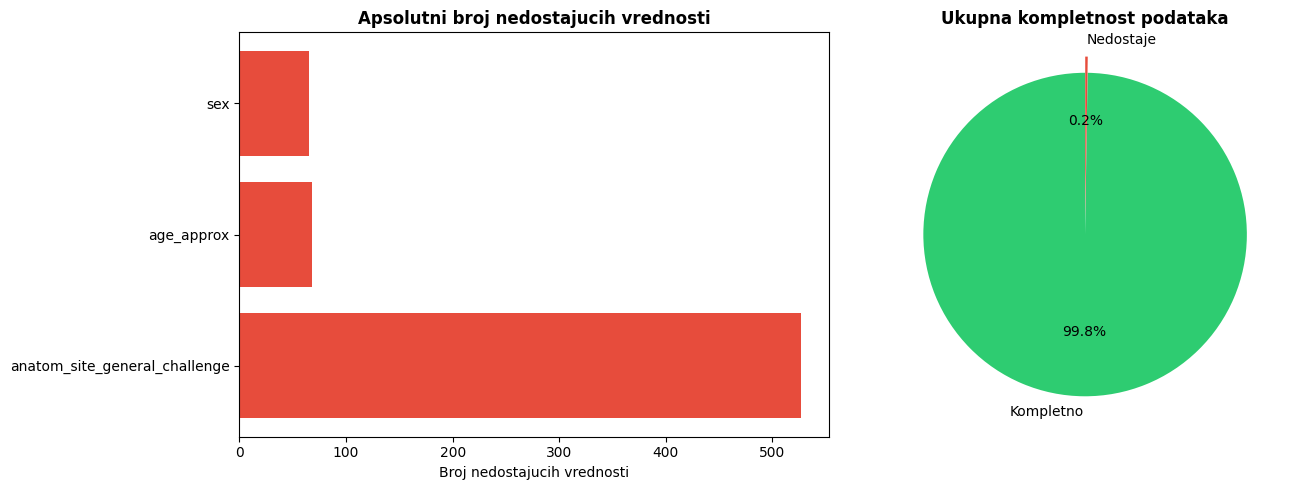

In [7]:
print("\n" + "="*60)
print("ANALIZA NEDOSTAJUCIH VREDNOSTI")
print("="*60)

missing_data = pd.DataFrame({
    'kolona': df.columns,
    'ukupno_nedostajucih': df.isnull().sum().values,
    'procenat_nedostajucih': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['ukupno_nedostajucih'] > 0].sort_values('procenat_nedostajucih', ascending=False)

if len(missing_data) > 0:
    print("\n Kolone sa nedostajucim vrednostima: ")
    print(missing_data.to_string(index=False))

    # Vizuelizacija nedostajucih vrednosti
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Bar plot
    axes[0].barh(missing_data['kolona'], missing_data['ukupno_nedostajucih'], color='#e74c3c')
    axes[0].set_xlabel('Broj nedostajucih vrednosti')
    axes[0].set_title('Apsolutni broj nedostajucih vrednosti', fontweight='bold')

    # Pie chart za ukupan procenat kompleksnosti
    total_missing = df.isnull().sum().sum()
    total_cells = df.size
    complete_pct = (total_cells - total_missing) / total_cells * 100

    axes[1].pie([complete_pct, 100-complete_pct],
                labels=['Kompletno', 'Nedostaje'],
                autopct='%1.1f%%',
                colors=['#2ecc71', '#e74c3c'],
                explode=(0, 0.1),
                startangle=90)
    axes[1].set_title('Ukupna kompletnost podataka', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('Nema nedostajucih vrednosti u datasetu!')

## 3. Analiza ciljne promenljive
Ispitana je distribucija ciljne promenljive (npr. benigno vs. maligno). Posebno je analizirana neuravnoteženost klasa, što je ključno za kasnije modelovanje jer može uticati na performanse modela.

Uočen je disbalans između klasa - jedna klasa je znatno zastupljenija od druge. Ovo može dovesti do pristrasnog modela, pa će biti potrebno koristiti tehnike balansiranja ili odgovarajuće metrike evaluacije.

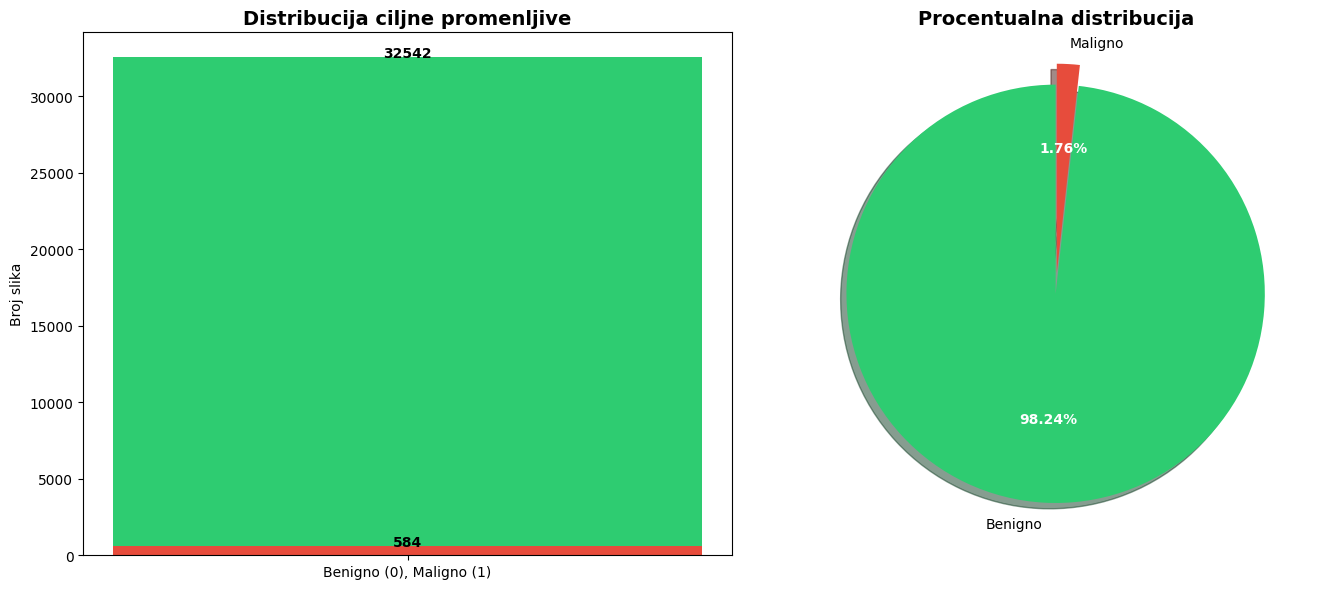

Ovo je izrazito nebalansiran dataset!
   Malignih slucajeva ima samo 1.76%


In [8]:
# Distribucija ciljne promenljive
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Benigno (0), Maligno (1)'], target_counts.values, color=colors)
axes[0].set_title('Distribucija ciljne promenljive', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Broj slika')
for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count}', ha='center', fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(target_counts.values,
                                       labels=['Benigno', 'Maligno'],
                                       colors=colors,
                                       startangle=90,
                                       explode=(0, 0.1),
                                       shadow=True,
                                       autopct=lambda pct: f'{pct:.2f}%')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[1].set_title('Procentualna distribucija', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Ovo je izrazito nebalansiran dataset!")
print(f"   Malignih slucajeva ima samo {target_percentages[1]:.2f}%")

## 4. Analiza demografskih podataka
Analizirane su demografske karakteristike pacijenata, kao što su pol i starost. Cilj je da se utvrdi da li postoje obrasci ili bias u podacima.

### 4.1 Analiza pola

ANALIZA PO POLU

 Nedostaje pol za 65 slika (0.20%)


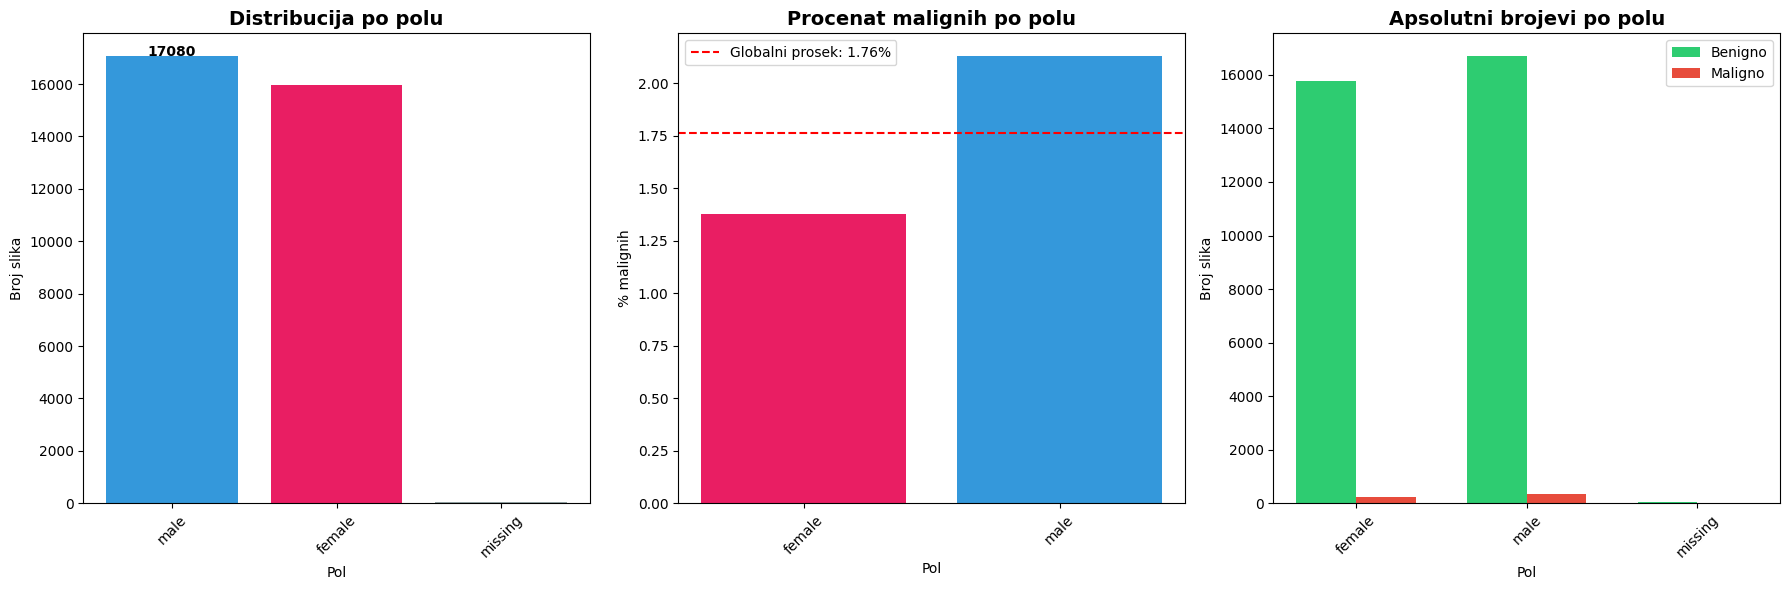

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


 Hi-kvadrat test za pol i dijagnozu (samo poznati polovi): 
   x² = 26.6534
   p-vrednost = 0.000000
  Postoji statisticki znacajna povezanost


In [9]:
print("="*60)
print("ANALIZA PO POLU")
print("="*60)

# Prikaz nedostajucih vrednosti za pol
sex_missing = df['sex'].isnull().sum()
if sex_missing > 0:
    print(f"\n Nedostaje pol za {sex_missing} slika ({sex_missing/len(df)*100:.2f}%)")

    fig, axes = plt.subplots(1, 3, figsize=(18,6))

    # 1. Distribucija po polu
    sex_data = df['sex'].fillna('missing').value_counts()
    colors_sex = {'male': '#3498db', 'female': '#e91e63', 'missing': '#95a5a6'}
    bar_colors = [colors_sex.get(x, '#95a5a6') for x in sex_data.index]

    axes[0].bar(sex_data.index, sex_data.values, color=bar_colors)
    axes[0].set_title('Distribucija po polu', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Broj slika')
    axes[0].set_xlabel('Pol')
    axes[0].tick_params(axis='x', rotation=45)

    # Dodavanje brojeva na barove
    for i, (idx, val) in enumerate(sex_data.items()):
        axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

         # Procenat malignih po polu
        sex_target = df.groupby('sex')['target'].mean() * 100
        if len(sex_target) > 0:
            colors_target = ['#3498db' if x == 'male' else '#e91e63' for x in sex_target.index]
            axes[1].bar(sex_target.index, sex_target.values, color=colors_target)
            axes[1].set_title('Procenat malignih po polu', fontsize=14, fontweight='bold')
            axes[1].set_ylabel('% malignih')
            axes[1].set_xlabel('Pol')
            axes[1].axhline(y=target_percentages[1], color='red', linestyle='--', 
                            label=f'Globalni prosek: {target_percentages[1]:.2f}%')
            axes[1].legend()
            axes[1].tick_params(axis='x', rotation=45)

        # 3. Apsolutni brojevi malignih po polu
        df_sex_analysis = df.copy()
        df_sex_analysis['sex_analysis'] = df_sex_analysis['sex'].fillna('missing')

        malignant_by_sex = df_sex_analysis[df_sex_analysis['target'] == 1]['sex_analysis'].value_counts()
        benign_by_sex = df_sex_analysis[df_sex_analysis['target'] == 0]['sex_analysis'].value_counts()

        all_cats = sorted(set(malignant_by_sex.index) | set(benign_by_sex.index))
        benign_values = [benign_by_sex.get(cat, 0) for cat in all_cats]
        malignant_values = [malignant_by_sex.get(cat, 0) for cat in all_cats]

        x = np.arange(len(all_cats))
        width = 0.35

        axes[2].bar(x - width/2, benign_values, width, label='Benigno', color='#2ecc71')
        axes[2].bar(x + width/2, malignant_values, width, label='Maligno', color='#e74c3c')
        axes[2].set_title('Apsolutni brojevi po polu', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Pol')
        axes[2].set_ylabel('Broj slika')
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(all_cats)
        axes[2].legend()
        axes[2].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

        # Statisticki test
    df_known_sex = df[df['sex'].notna()]
    if len(df_known_sex) > 0:
        contigency_table = pd.crosstab(df_known_sex['sex'], df_known_sex['target'])
        chi2, p_value, dof, expected = stats.chi2_contingency(contigency_table)
        print(f"\n Hi-kvadrat test za pol i dijagnozu (samo poznati polovi): ")
        print(f"   x² = {chi2:.4f}")
        print(f"   p-vrednost = {p_value:.6f}")
        print(f"  {'Postoji statisticki znacajna povezanost' if p_value < 0.05 else 'Nema statisticke povezanosti'}")

### 4.2 Analiza starosti
Detaljno je ispitana raspodela starosti pacijenata:
- osnovne statistike (srednja vrednost, medijana, opseg)
- identifikacija ekstremnih vrednosti
- povezanost starosti sa ciljnom promenljivom


ANALIZA STAROSTI

 Nedostaje starost za 68 slika (0.21%)


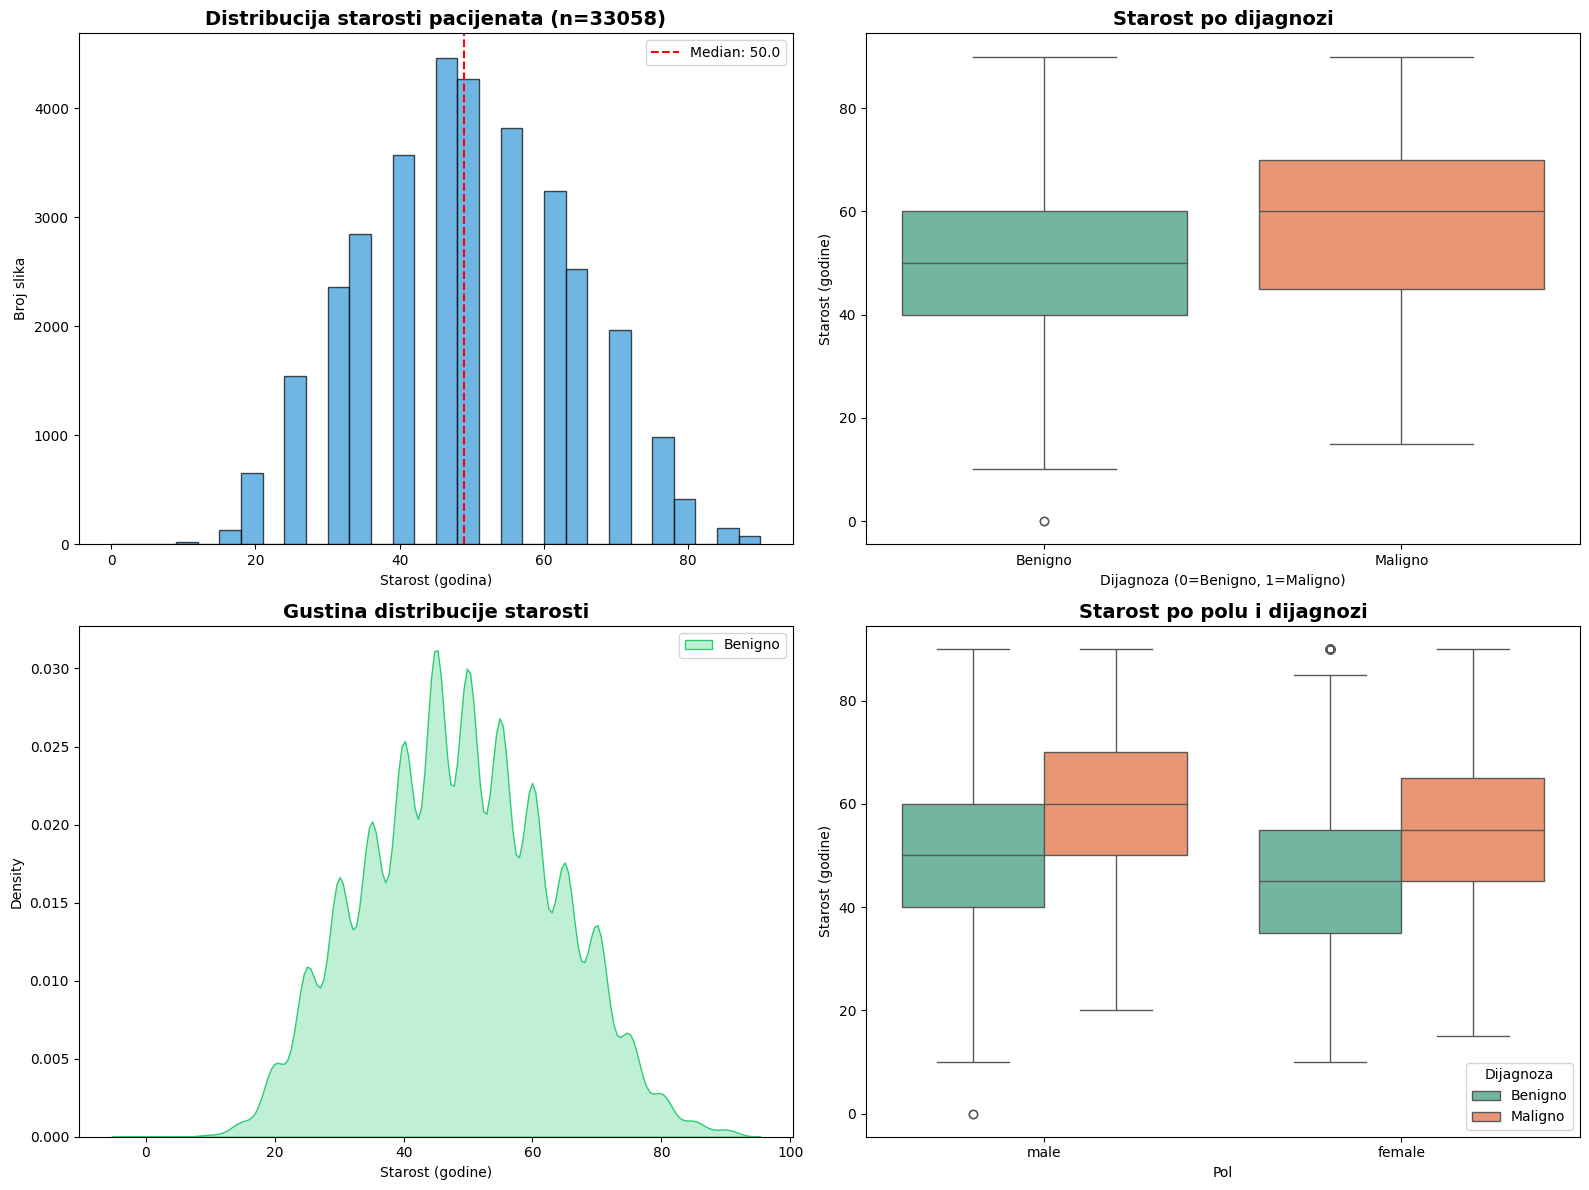

<Figure size 640x480 with 0 Axes>


 T-test za starost (Benigno vs Maligno): 
   Benigno - mean: 48.70, std: 14.29, n=32474
   t-statistika = -15.7654
   p-vrednost = 0.0000000000
   Postoji statisticki znacajna razlika


In [10]:
print("\n" + "="*60)
print("ANALIZA STAROSTI")
print("="*60)

# Prikaz nedostajucih vrednosti za starost
age_missing = df['age_approx'].isnull().sum()
if age_missing > 0:
    print(f"\n Nedostaje starost za {age_missing} slika ({age_missing/len(df)*100:.2f}%)")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Histogram starosti (samo poznate vrednosti)
    age_known = df['age_approx'].dropna()
    if len(age_known) > 0:
        axes[0, 0].hist(age_known, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0, 0].set_title(f'Distribucija starosti pacijenata (n={len(age_known)})',
            fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Starost (godina)')
        axes[0, 0].set_ylabel('Broj slika')
        axes[0, 0].axvline(age_known.mean(), color='red', linestyle='--',
            label=f'Median: {age_known.median():.1f}')
        axes[0, 0].legend()
    else:
        axes[0, 0].text(0.5, 0.5, 'Nema podataka o starosti', ha='center', va='center')

    # 2. Box plot starosti po dijagnozi (samo poznate vrednosti)
    df_age_known = df[df['age_approx'].notna()]
    if len(df_age_known) > 0:
        sns.boxplot(data=df_age_known, x='target', y='age_approx', ax=axes[0, 1], palette='Set2')
        axes[0, 1].set_title('Starost po dijagnozi', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Dijagnoza (0=Benigno, 1=Maligno)')
        axes[0, 1].set_ylabel('Starost (godine)')
        axes[0, 1].set_xticklabels(['Benigno', 'Maligno'])
    else:
        axes[0, 1].text(0.5, 0.5, 'Nema podataka', ha='center', va='center')

    # 3. KDE plot starosti po dijagnozi
    if len(df_age_known) > 0:
        for target_val, color, label in [(0, '#2ecc71', 'Benigno'), (1, '#e74c3c', 'Maligno')]:
            subset = df_age_known[df_age_known['target'] == target_val]['age_approx']
            if len(subset) > 0:
                sns.kdeplot(subset, ax=axes[1, 0], color=color, label=label, fill=True, alpha=0.3)
                axes[1, 0].set_title('Gustina distribucije starosti', fontsize=14, fontweight='bold')
                axes[1, 0].set_xlabel('Starost (godine)')
                axes[1, 0].legend()
            else:
                axes[1, 0].text(0.5, 0.5, 'Nema podataka', ha='center', va='center')

            # 4. Starost po polu i dijagnozi (ako pol postoji)
            if 'sex' in df.columns:
                df_combined = df[(df['age_approx'].notna()) & (df['sex'].notna())]
                if len(df_combined) > 0:
                    sns.boxplot(data=df_combined, x='sex', y='age_approx', hue='target', ax=axes[1, 1], palette='Set2')
                    axes[1, 1].set_title('Starost po polu i dijagnozi', fontsize=14, fontweight='bold')
                    axes[1, 1].set_xlabel('Pol')
                    axes[1, 1].set_ylabel('Starost (godine)')
                    if axes[1, 1].get_legend():
                        handles, labels = axes[1, 1].get_legend_handles_labels()
                        axes[1, 1].legend(handles, ['Benigno', 'Maligno'], title='Dijagnoza')
                else:
                    axes[1, 1].text(0.5, 0.5, 'Nema podataka o polu', ha='center', va='center')

                plt.tight_layout()
                plt.show()

        # Statisticki test - samo za poznate vrednosti
        benign_age = df[df['target'] == 0]['age_approx'].dropna()
        malignant_age = df[df['target'] == 1]['age_approx'].dropna()

        if len(benign_age) > 0 and len(malignant_age) > 0:
            t_stat, p_val = stats.ttest_ind(benign_age, malignant_age)
            print(f"\n T-test za starost (Benigno vs Maligno): ")
            print(f"   Benigno - mean: {benign_age.mean():.2f}, std: {benign_age.std():.2f}, n={len(benign_age)}")
            print(f"   t-statistika = {t_stat:.4f}")
            print(f"   p-vrednost = {p_val:.10f}")
            print(f"   {'Postoji statisticki znacajna razlika' if p_val < 0.05 else 'Nema statisticki znacajne razlike'}")

## 5. Analiza anatomske lokacije
Analizirana je raspodela lezija po delovima tela. Ova informacija može biti važna jer određene lokacije mogu imati veću verovatnoću pojave malignih promena.


ANALIZA ANATOMSKE LOKACIJE

 Nedostaje lokacija za 527 slika (1.59%)


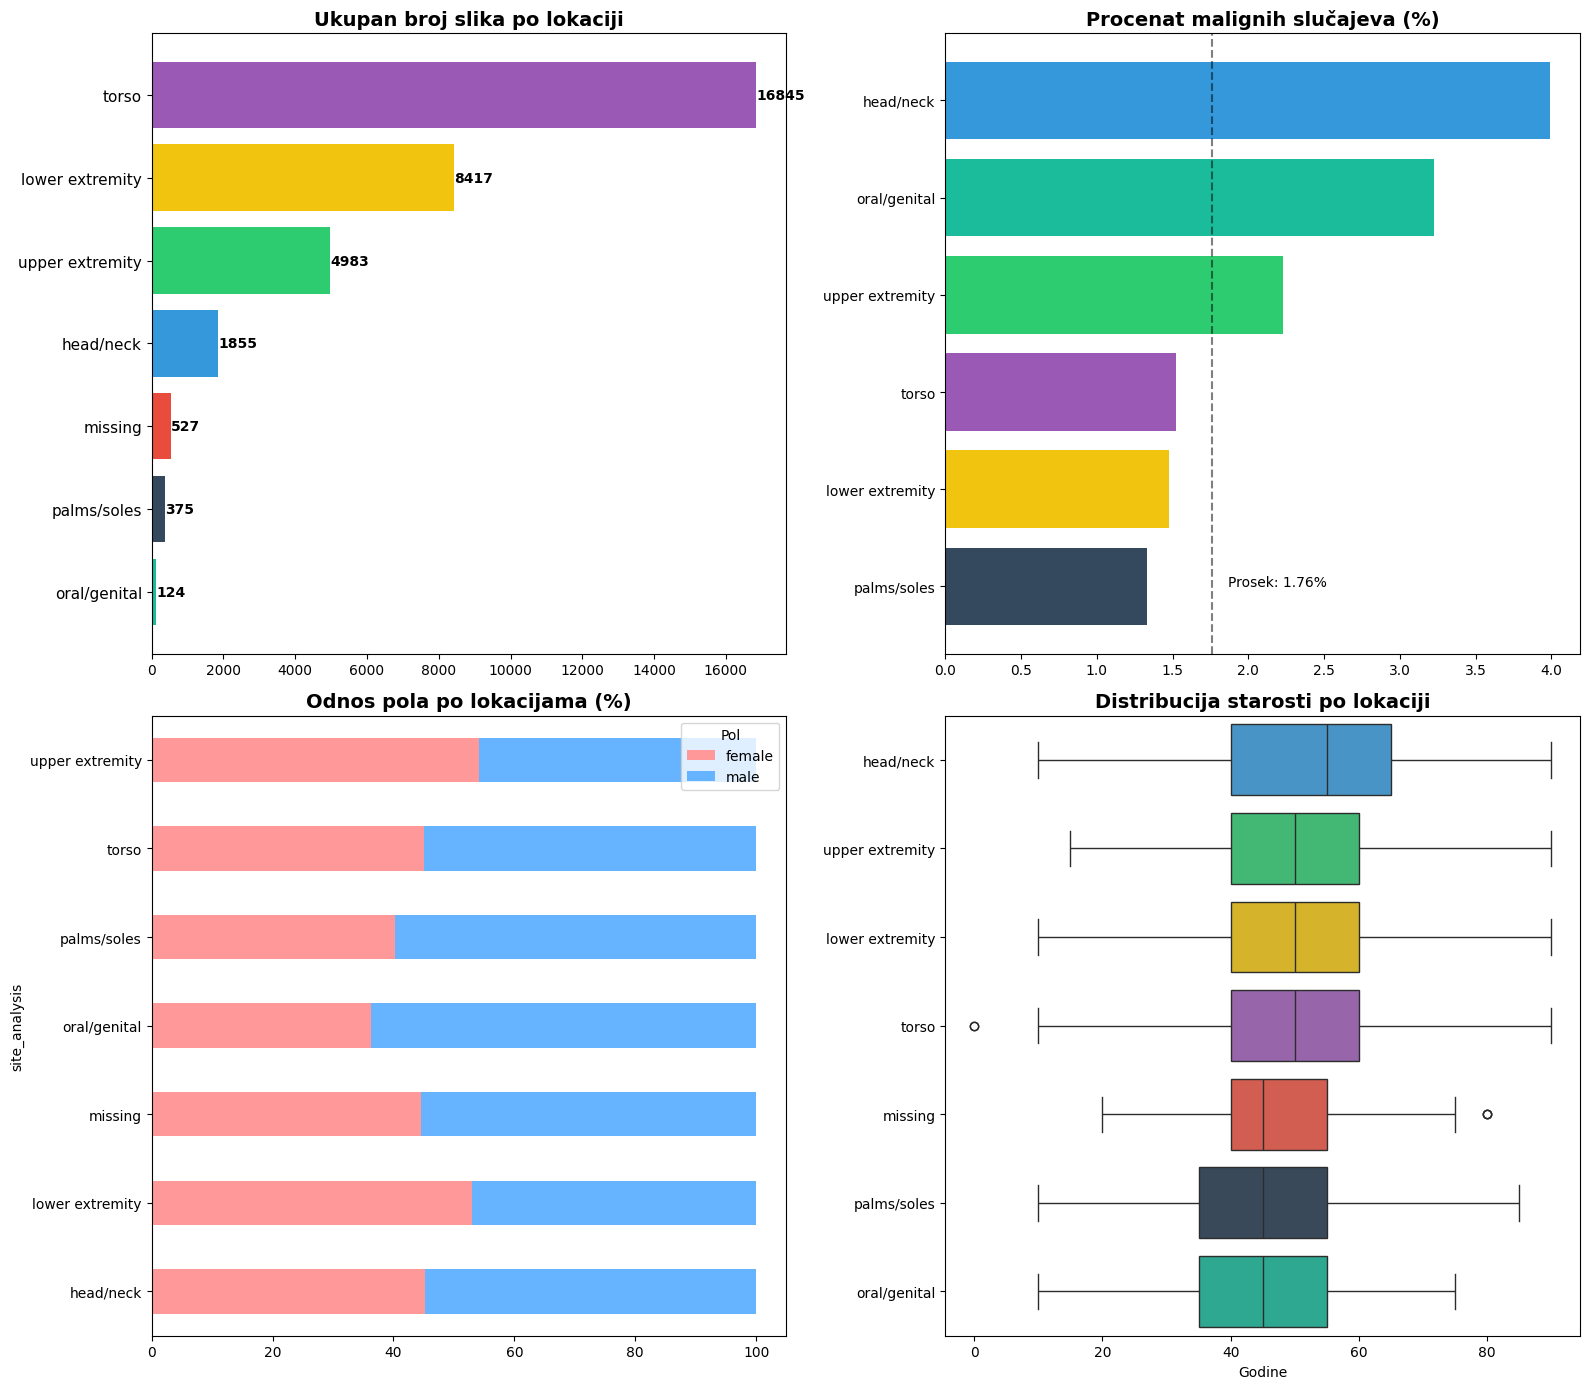


Hi-kvadrat test za anatomsku lokaciju i dijagnozu:
  χ² = 70.7495
  p-vrednost = 0.0000000000
  Postoji statistički značajna povezanost


In [11]:
print("\n" + "="*60)
print("ANALIZA ANATOMSKE LOKACIJE")
print("="*60)

# Prikaz nedostajućih vrednosti
site_missing = df['anatom_site_general_challenge'].isnull().sum()
df_site = df.copy()
df_site['site_analysis'] = df_site['anatom_site_general_challenge'].fillna('missing')

if site_missing:
    print(f"\n Nedostaje lokacija za {site_missing} slika ({site_missing/len(df)*100:.2f}%)")

# 1. Definisanje konzistentne mape boja za sve lokacije
unique_sites = [s for s in df_site['site_analysis'].unique() if s != 'missing']
custom_palette = ['#3498db', '#2ecc71', '#f1c40f', '#9b59b6', '#34495e', '#1abc9c', '#e67e22']
site_color_map = {site: custom_palette[i % len(custom_palette)] for i, site in enumerate(unique_sites)}
site_color_map['missing'] = '#e74c3c' # Crvena za nedostajuće

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Distribucija lokacija
site_counts = df_site['site_analysis'].value_counts(ascending=True)
y_pos = np.arange(len(site_counts))
colors_site = [site_color_map[label] for label in site_counts.index]

axes[0, 0].barh(y_pos, site_counts.values, color=colors_site)
axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels(site_counts.index, fontsize=11)
axes[0, 0].set_title('Ukupan broj slika po lokaciji', fontsize=14, fontweight='bold')
for i, v in enumerate(site_counts.values):
    axes[0, 0].text(v + 5, i, str(v), va='center', fontweight='bold')

# 2. Procenat malignih po lokaciji
site_target = df.groupby('anatom_site_general_challenge')['target'].mean() * 100
site_target = site_target.sort_values(ascending=True)

if len(site_target) > 0:
    y_pos2 = np.arange(len(site_target))
    colors_target = [site_color_map[label] for label in site_target.index]
    
    axes[0, 1].barh(y_pos2, site_target.values, color=colors_target)
    axes[0, 1].set_yticks(y_pos2)
    axes[0, 1].set_yticklabels(site_target.index)
    axes[0, 1].set_title('Procenat malignih slučajeva (%)', fontsize=14, fontweight='bold')
    
    global_avg = df['target'].mean() * 100
    axes[0, 1].axvline(global_avg, color='black', linestyle='--', alpha=0.5)
    axes[0, 1].text(global_avg + 0.1, 0, f'Prosek: {global_avg:.2f}%', rotation=0, color='black')

# 3. Odnos pola i lokacije
# Koristimo crosstab da vidimo gde se mladeži najčešće pojavljuju kod muškaraca/žena
gender_site = pd.crosstab(df_site['site_analysis'], df_site['sex'], normalize='index') * 100
gender_site.plot(kind='barh', stacked=True, ax=axes[1, 0], color=['#ff9999','#66b3ff'])
axes[1, 0].set_title('Odnos pola po lokacijama (%)', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Pol', loc='upper right')

# 4. Starost pacijenata po lokaciji
sns.boxplot(data=df_site, x='age_approx', y='site_analysis', ax=axes[1, 1], palette=site_color_map)
axes[1, 1].set_title('Distribucija starosti po lokaciji', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Godine')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

# Hi-kvadrat test - samo za poznate vrednosti
df_site_known = df[df['anatom_site_general_challenge'].notna()]
if len(df_site_known) > 0:
    contingency_site = pd.crosstab(df_site_known['anatom_site_general_challenge'], 
                                  df_site_known['target'])
    chi2_site, p_site, dof_site, expected_site = stats.chi2_contingency(contingency_site)
    print(f"\nHi-kvadrat test za anatomsku lokaciju i dijagnozu:")
    print(f"  χ² = {chi2_site:.4f}")
    print(f"  p-vrednost = {p_site:.10f}")
    print(f"  {'Postoji statistički značajna povezanost' if p_site < 0.05 else 'Nema statistički značajne povezanosti'}")

## 6. Analiza na nivou pacijenta
Ispitano je koliko slika pripada jednom pacijentu i da li postoji zavisnost između uzoraka. Ovo je važno kako bi se izbeglo “curenje informacija” između trening i test skupa u kasnijim fazama.


ANALIZA NA NIVOU PACIJENTA

 Statistika po pacijentu: 
    Ukupno pacijenta: 2056
    Prosecan broj slika po pacijentu: 16.11
    Medijana broja slika po pacijentu: 12.00
    Min slika po pacijentu: 2
    Max slika po pacijentu: 115
  Pacijenti sa malignim slučajevima: 428 (20.82%)
  Pacijenata bez podataka o polu: 2 (0.10%)
  Pacijenata bez podataka o starosti: 3 (0.15%)


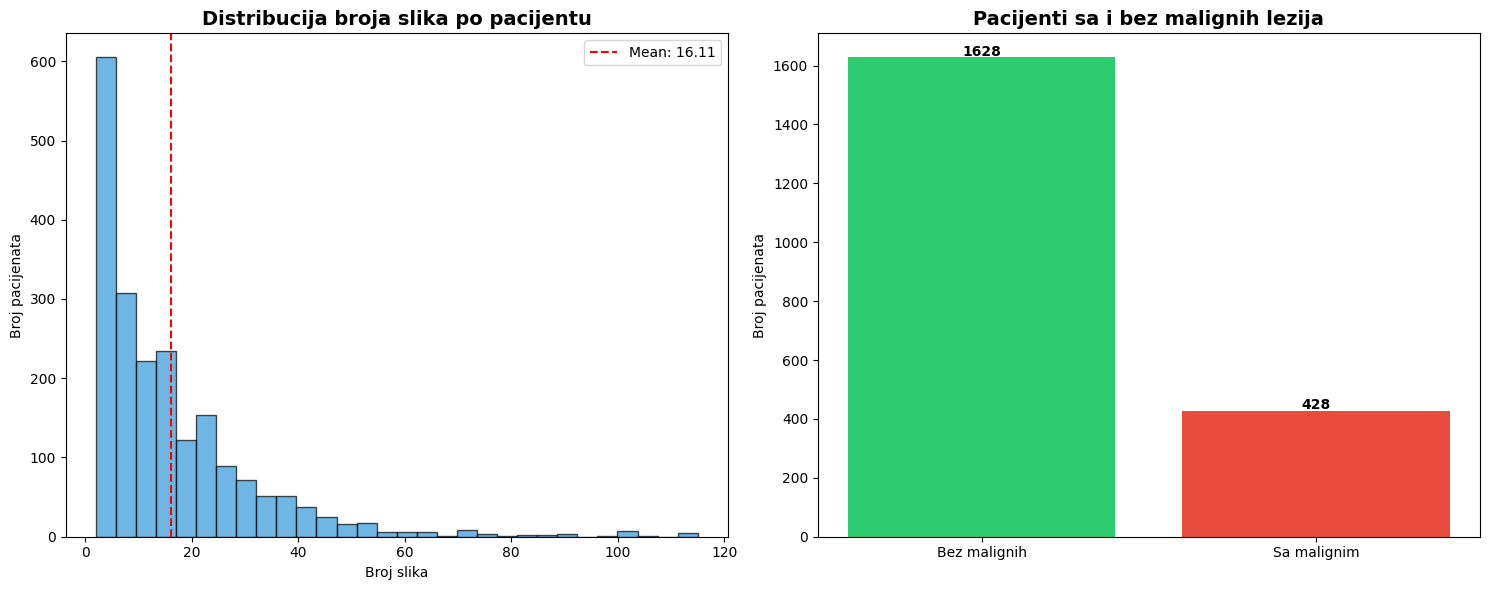

In [12]:
print("\n" + "="*60)
print("ANALIZA NA NIVOU PACIJENTA")
print("="*60)

# Analiza po pacijentu
patient_stats = df.groupby('patient_id').agg({
    'image_name': 'count',
    'target': ['mean', 'sum']
}).round(2)

patient_stats.columns = ['broj_slika', 'procenat_malignih', 'broj_malignih']
patient_stats = patient_stats.reset_index()

# Dodavanje demografskih podataka
if 'sex' in df.columns:
    # Uzimamo prvu poznatu vrednost za svakog pacijenta
    sex_first = df[df['sex'].notna()].groupby('patient_id')['sex'].first()
    patient_stats['pol'] = patient_stats['patient_id'].map(sex_first)
    # Obelezavamo pacijente bez podataka o polu
    patient_stats['pol_missing'] = patient_stats['pol'].isna()

if 'age_approx' in df.columns:
    age_first = df[df['age_approx'].notna()].groupby('patient_id')['age_approx'].first()
    patient_stats['starost'] = patient_stats['patient_id'].map(age_first)
    patient_stats['starost_missing'] = patient_stats['starost'].isna()

print(f"\n Statistika po pacijentu: ")
print(f"    Ukupno pacijenta: {len(patient_stats)}")
print(f"    Prosecan broj slika po pacijentu: {patient_stats['broj_slika'].mean():.2f}")
print(f"    Medijana broja slika po pacijentu: {patient_stats['broj_slika'].median():.2f}")
print(f"    Min slika po pacijentu: {patient_stats['broj_slika'].min()}")
print(f"    Max slika po pacijentu: {patient_stats['broj_slika'].max()}")
print(f"  Pacijenti sa malignim slučajevima: {(patient_stats['broj_malignih'] > 0).sum()} "
      f"({((patient_stats['broj_malignih'] > 0).sum() / len(patient_stats) * 100):.2f}%)")

if 'pol_missing' in patient_stats.columns:
    pol_missing_count = patient_stats['pol_missing'].sum()
    print(f"  Pacijenata bez podataka o polu: {pol_missing_count} "
          f"({pol_missing_count/len(patient_stats)*100:.2f}%)")

if 'starost_missing' in patient_stats.columns:
    starost_missing_count = patient_stats['starost_missing'].sum()
    print(f"  Pacijenata bez podataka o starosti: {starost_missing_count} "
          f"({starost_missing_count/len(patient_stats)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribucija broja slika po pacijentu
axes[0].hist(patient_stats['broj_slika'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribucija broja slika po pacijentu', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Broj slika')
axes[0].set_ylabel('Broj pacijenata')
axes[0].axvline(patient_stats['broj_slika'].mean(), color='red', linestyle='--', 
                label=f'Mean: {patient_stats["broj_slika"].mean():.2f}')
axes[0].legend()

# Pacijenti sa malignim vs bez malignih
malignant_patients = patient_stats[patient_stats['broj_malignih'] > 0]
benign_patients = patient_stats[patient_stats['broj_malignih'] == 0]

axes[1].bar(['Bez malignih', 'Sa malignim'], [len(benign_patients), len(malignant_patients)], 
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Pacijenti sa i bez malignih lezija', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Broj pacijenata')

# Dodavanje brojeva na barove
for i, v in enumerate([len(benign_patients), len(malignant_patients)]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Analiza slika

U ovoj fazi analiziran je vizuelni sadržaj dataset-a:
- dimenzije slika
- odnos širine i visine
- kvalitet i uniformnost
- potencijalni duplikati
- vizuelni pregled uzoraka

Cilj je da se razume kakve ulazne podatke model dobija.

In [13]:
print("\n" + "="*60)
print("ANALIZA SLIKA")
print("="*60)

def get_image_info(img_file):
    img_path = os.path.join(IMAGE_FOLDER, img_file)
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            return {
                'image_name': img_file.split('.')[0],
                'width': width,
                'height': height,
                'aspect_ratio': width / height if height > 0 else 0,
                'area': width * height
            }
    except:
        return None

if os.path.exists(IMAGE_FOLDER):
    image_files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')]
    
    image_dimensions = []
    
    print(f"Pokrećem analizu {len(image_files)} slika...")
    
    with ThreadPoolExecutor(max_workers=32) as executor:
        results = list(tqdm(executor.map(get_image_info, image_files), total=len(image_files)))

    image_dimensions = [r for r in results if r is not None]
    
    print(f"\nUspešno: {len(image_dimensions)}")
    print(f"Greške: {len(image_files) - len(image_dimensions)}")


ANALIZA SLIKA
Pokrećem analizu 33126 slika...


100%|██████████| 33126/33126 [08:58<00:00, 61.55it/s] 


Uspešno: 33126
Greške: 0



Statistika dimenzija slika: 
              width        height  aspect_ratio          area
count  33126.000000  33126.000000  33126.000000  3.312600e+04
mean    4039.630381   2678.758256      1.527957  1.383590e+07
std     2109.145590   1437.617626      0.155173  1.030617e+07
min      640.000000    480.000000      0.664179  3.072000e+05
25%     1872.000000   1053.000000      1.500000  1.971216e+06
50%     5184.000000   3456.000000      1.500000  1.791590e+07
75%     6000.000000   4000.000000      1.500000  2.400000e+07
max     6000.000000   6000.000000      1.781473  2.400000e+07


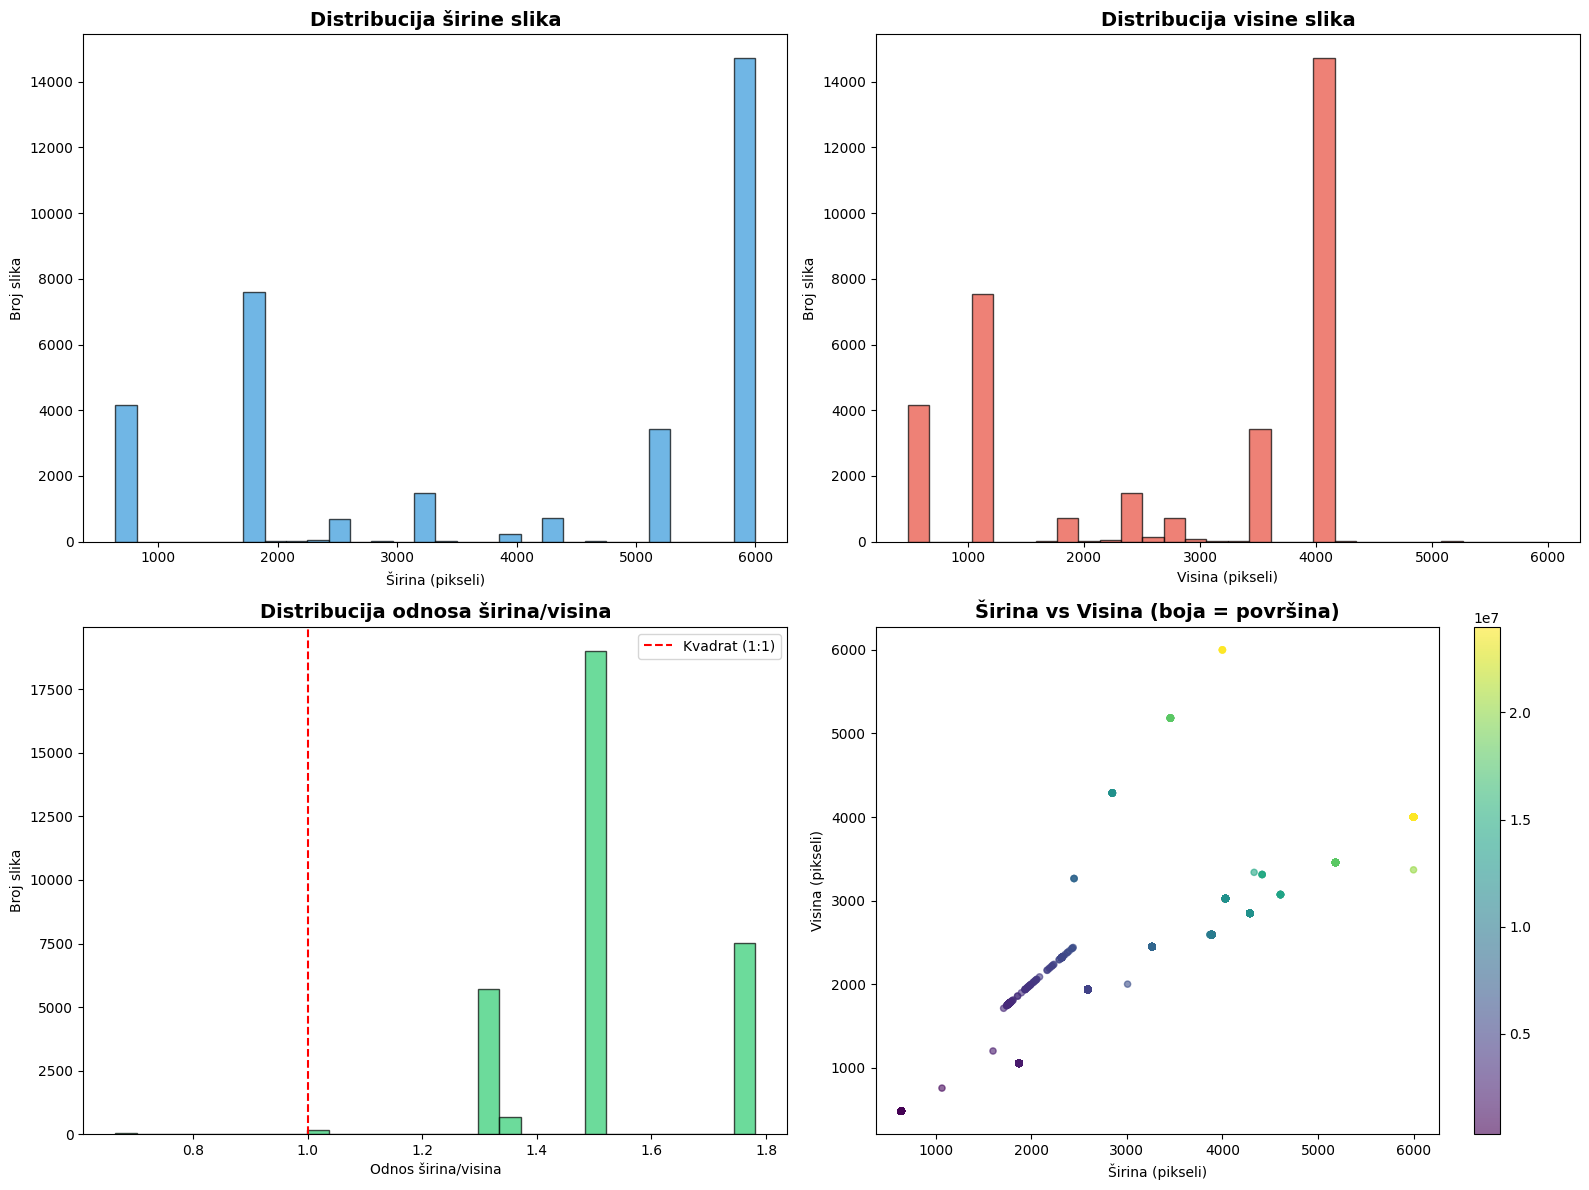


Primeri BENIGNIH slika:


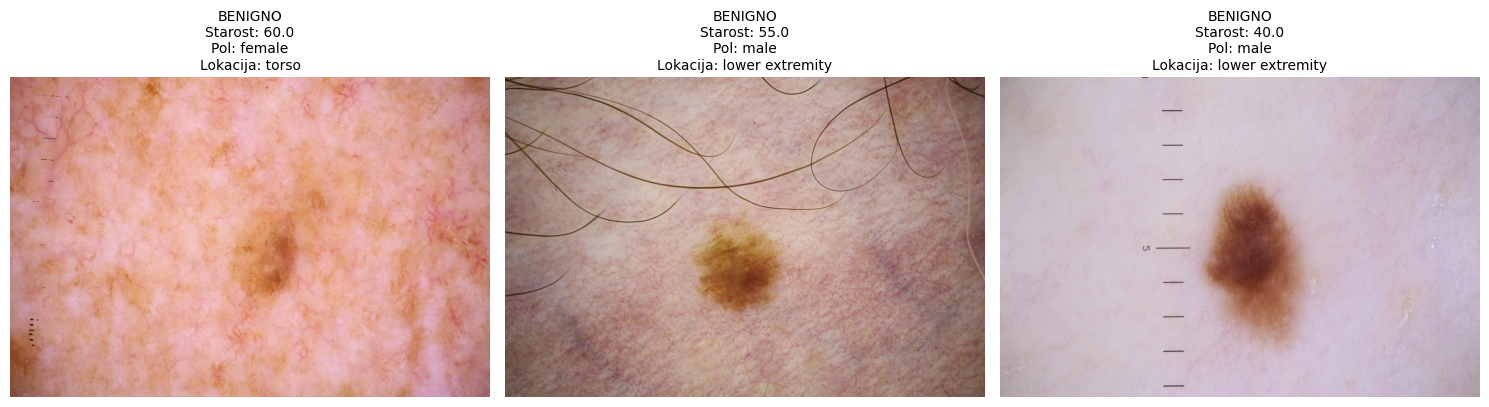


Primeri MALIGNIH slika:


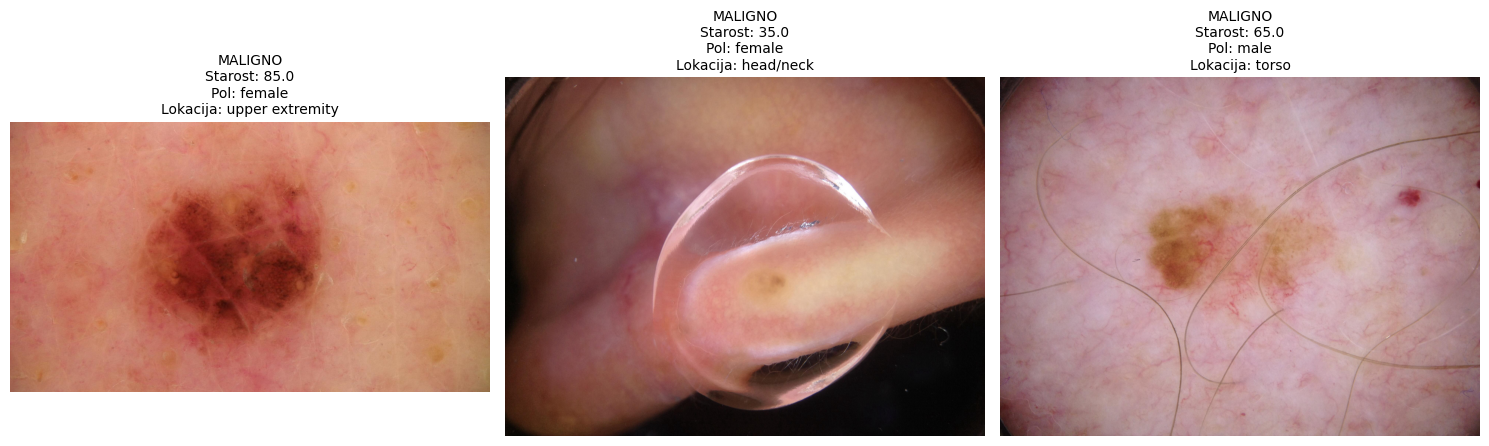

In [18]:
valid_images = len(image_dimensions)
if valid_images > 0:
    df_images = pd.DataFrame(image_dimensions)

    print("\nStatistika dimenzija slika: ")
    print(df_images[['width', 'height', 'aspect_ratio', 'area']].describe())

    # Vizuelizacija dimenzija slika
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Distribucija sirine
    axes[0, 0].hist(df_images['width'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribucija širine slika', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Širina (pikseli)')
    axes[0, 0].set_ylabel('Broj slika')

    # Distribucija visine
    axes[0, 1].hist(df_images['height'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Distribucija visine slika', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Visina (pikseli)')
    axes[0, 1].set_ylabel('Broj slika')

    # Odnos širine i visine
    axes[1, 0].hist(df_images['aspect_ratio'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Distribucija odnosa širina/visina', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Odnos širina/visina')
    axes[1, 0].set_ylabel('Broj slika')
    axes[1, 0].axvline(1, color='red', linestyle='--', label='Kvadrat (1:1)')
    axes[1, 0].legend()

    # Scatter plot širina vs visina
    scatter = axes[1, 1].scatter(df_images['width'], df_images['height'], 
                                 c=df_images['area'], cmap='viridis', alpha=0.6, s=20)
    axes[1, 1].set_title('Širina vs Visina (boja = površina)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Širina (pikseli)')
    axes[1, 1].set_ylabel('Visina (pikseli)')
    plt.colorbar(scatter, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()

    # Vizuelni pregled slika
    def plot_sample_images(df, image_folder, n_samples=3, target_class=None):
        """Prikazuje nasumične uzorke slika iz dataset-a"""
        if target_class is not None:
            sample_df = df[df['target'] == target_class].sample(min(n_samples, len(df[df['target'] == target_class])))
            title_prefix = "MALIGNO" if target_class == 1 else "BENIGNO"
        else:
            sample_df = df.sample(min(n_samples, len(df)))
            title_prefix = "NASUMIČNI UZORCI"
        
        fig, axes = plt.subplots(1, len(sample_df), figsize=(5*len(sample_df), 5))
        if len(sample_df) == 1:
            axes = [axes]
        
        for i, (idx, row) in enumerate(sample_df.iterrows()):
            img_path = os.path.join(image_folder, row['image_name'] + '.jpg')
            if os.path.exists(img_path):
                img = Image.open(img_path)
                axes[i].imshow(img)
                
                # Kreiranje informativnog naslova (samo postojeći podaci)
                title_parts = [f"{title_prefix}"]
                if pd.notna(row.get('age_approx')):
                    title_parts.append(f"Starost: {row['age_approx']}")
                if pd.notna(row.get('sex')):
                    title_parts.append(f"Pol: {row['sex']}")
                if pd.notna(row.get('anatom_site_general_challenge')):
                    title_parts.append(f"Lokacija: {row['anatom_site_general_challenge']}")
                
                axes[i].set_title('\n'.join(title_parts), fontsize=10)
                axes[i].axis('off')
            else:
                axes[i].text(0.5, 0.5, f"Slika ne postoji\n{row['image_name']}", 
                           ha='center', va='center', fontsize=10)
                axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    print("\nPrimeri BENIGNIH slika:")
    plot_sample_images(df, IMAGE_FOLDER, n_samples=3, target_class=0)
    
    print("\nPrimeri MALIGNIH slika:")
    plot_sample_images(df, IMAGE_FOLDER, n_samples=3, target_class=1)

## 8. Korelaciona analiza
Ispitana je međusobna povezanost numeričkih promenljivih pomoću korelacione matrice. Ovo pomaže u identifikaciji redundantnih informacija i potencijalno važnih prediktora.


KORELACIONA ANALIZA

Broj potpunih slučajeva za korelacionu analizu: 32531 od ukupno 33126 (98.20%)


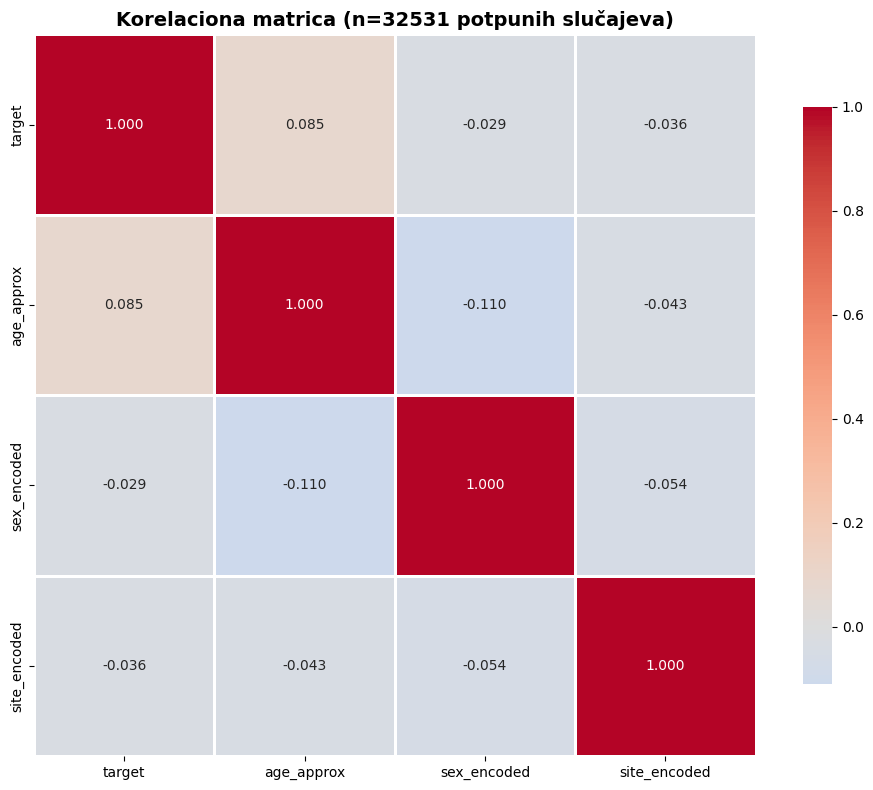

In [16]:
print("\n" + "="*60)
print("KORELACIONA ANALIZA")
print("="*60)

# Koristimo samo redove gde su sve relevantne vrednosti poznate
df_complete = df.copy()

# Selektujemo kolone za analizu
cols_for_corr = ['target']
if 'age_approx' in df.columns:
    cols_for_corr.append('age_approx')
if 'sex' in df.columns:
    cols_for_corr.append('sex')
if 'anatom_site_general_challenge' in df.columns:
    cols_for_corr.append('anatom_site_general_challenge')

# Uklanjamo redove sa missing vrednostima
df_complete = df_complete[cols_for_corr].dropna()

print(f"\nBroj potpunih slučajeva za korelacionu analizu: {len(df_complete)} od ukupno {len(df)} "
      f"({len(df_complete)/len(df)*100:.2f}%)")

if len(df_complete) > 0:
    # Encoding kategoričkih varijabli
    df_corr = df_complete.copy()
    
    if 'sex' in df_corr.columns:
        df_corr['sex_encoded'] = df_corr['sex'].map({'male': 0, 'female': 1})
        df_corr = df_corr.drop('sex', axis=1)
    
    if 'anatom_site_general_challenge' in df_corr.columns:
        df_corr['site_encoded'] = pd.factorize(df_corr['anatom_site_general_challenge'])[0]
        df_corr = df_corr.drop('anatom_site_general_challenge', axis=1)
    
    # Korelaciona matrica
    corr_matrix = df_corr.corr()
    
    # Vizuelizacija
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
    plt.title(f'Korelaciona matrica (n={len(df_complete)} potpunih slučajeva)', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 9. Zaključak i ključni nalazi
Sumirani su najvažniji uvidi iz analize:
- karakteristike dataset-a
- uočeni problemi (npr. nedostajuće vrednosti, neuravnoteženost klasa)
- potencijalni uticaji na modeliranje
- preporuke za naredne korake (preprocesiranje, augmentacija, balansiranje itd.)

In [17]:
print("\n" + "="*70)
print("KRAĆI PREGLED KLJUČNIH NALAZA")
print("="*70)

print(f"\nOsnovne informacije:")
print(f"   - Ukupno slika: {len(df)}")
print(f"   - Broj pacijenata: {df['patient_id'].nunique()}")
print(f"   - Prosečan broj slika po pacijentu: {len(df)/df['patient_id'].nunique():.2f}")

print(f"\nBalans klasa:")
print(f"   - Benignih: {target_counts.get(0, 0)} ({target_percentages.get(0, 0):.2f}%)")
print(f"   - Malignih: {target_counts.get(1, 0)} ({target_percentages.get(1, 0):.2f}%)")
print(f"   - Izrazito nebalansiran skup!")

print(f"\nNedostajuće vrednosti:")
total_missing = df.isnull().sum().sum()
total_cells = df.size
if total_missing > 0:
    print(f"   - Ukupno missing vrednosti: {total_missing} ({total_missing/total_cells*100:.2f}% svih polja)")
    for col in df.columns:
        missing = df[col].isnull().sum()
        if missing > 0:
            print(f"   - {col}: {missing} ({missing/len(df)*100:.2f}%)")
else:
    print("   - Nema nedostajućih vrednosti")

if 'age_approx' in df.columns:
    age_known = df['age_approx'].notna().sum()
    print(f"\nDemografija (samo poznati podaci):")
    print(f"   - Starost: podaci za {age_known}/{len(df)} slika ({age_known/len(df)*100:.1f}%)")
    if age_known > 0:
        print(f"   - Prosečna starost: {df['age_approx'].mean():.1f} godina")

if 'sex' in df.columns:
    sex_known = df['sex'].notna().sum()
    print(f"   - Pol: podaci za {sex_known}/{len(df)} slika ({sex_known/len(df)*100:.1f}%)")
    if sex_known > 0:
        sex_dist = df['sex'].value_counts(normalize=True) * 100
        for sex, pct in sex_dist.items():
            print(f"     {sex}: {pct:.1f}%")

print(f"\nKljučni izazovi za modelovanje:")
print(f"   1. Ekstremna nebalansiranost - koristiti tehnike kao što su klasni težinski faktori, "
      f"ili fokus na metrike poput AUC-ROC i F1-score")
print(f"   2. Nedostajući podaci - odlučiti strategiju za missing vrednosti:")
print(f"      - Ignorisati (modeli koji podržavaju missing)")
print(f"      - Dodeliti 'unknown' kategoriju")
print(f"      - Koristiti samo potpune slučajeve")
print(f"   3. Varijabilne dimenzije slika - potrebno definisati resize strategiju")
print(f"   4. Grupisanje po pacijentima - obezbediti da slike istog pacijenta ne budu "
      f"i u trening i u test setu")

print("\nEDA završena!")


KRAĆI PREGLED KLJUČNIH NALAZA

Osnovne informacije:
   - Ukupno slika: 33126
   - Broj pacijenata: 2056
   - Prosečan broj slika po pacijentu: 16.11

Balans klasa:
   - Benignih: 32542 (98.24%)
   - Malignih: 584 (1.76%)
   - Izrazito nebalansiran skup!

Nedostajuće vrednosti:
   - Ukupno missing vrednosti: 660 (0.25% svih polja)
   - sex: 65 (0.20%)
   - age_approx: 68 (0.21%)
   - anatom_site_general_challenge: 527 (1.59%)

Demografija (samo poznati podaci):
   - Starost: podaci za 33058/33126 slika (99.8%)
   - Prosečna starost: 48.9 godina
   - Pol: podaci za 33061/33126 slika (99.8%)
     male: 51.7%
     female: 48.3%

Ključni izazovi za modelovanje:
   1. Ekstremna nebalansiranost - koristiti tehnike kao što su klasni težinski faktori, ili fokus na metrike poput AUC-ROC i F1-score
   2. Nedostajući podaci - odlučiti strategiju za missing vrednosti:
      - Ignorisati (modeli koji podržavaju missing)
      - Dodeliti 'unknown' kategoriju
      - Koristiti samo potpune slučajeve
